# Neural Network Experiments
This notebook is a lightweight sandbox for primitive test runs using a PyTorch feedforward neural network.
Run cells in order from top to bottom.

In [123]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]


TWEET_FEATURES = [
   "text", "reply_count", "favorite_count", "num_urls", "num_mentions"
]

# Neural network hyperparameters
NN_PARAMS = {
    "hidden_dims": [256, 128, 64, 32], 
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "batch_size": 256,
    "epochs": 50,
    "patience": 7,  
    "random_state": 42,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9
PyTorch version: 2.11.0
Device: cpu


In [124]:
def resolve_users_csv(base_dir, dataset_entry):
    """Resolve dataset entry to a users.csv path."""
    candidates = [
        os.path.join(base_dir, dataset_entry),
        os.path.join(base_dir, dataset_entry, USERS_FILE),
        os.path.join(base_dir, dataset_entry, dataset_entry, USERS_FILE),
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p
    return None


def load_all_data(dataset_map, base_dir):
    """Load all configured datasets and attach binary labels."""
    frames = []
    missing_files = []

    for dataset_entry, label in dataset_map.items():
        path = resolve_users_csv(base_dir, dataset_entry)
        if path is None:
            missing_files.append(dataset_entry)
            continue

        df = pd.read_csv(
            path,
            encoding="utf-8",
            on_bad_lines="skip",
            low_memory=False,
        )
        df["label"] = int(label)
        df["source_file"] = dataset_entry
        frames.append(df)
        print(f"Loaded {dataset_entry}: {len(df):,} rows")

    if missing_files:
        print("\nMissing dataset entries:")
        for p in missing_files:
            print("-", p)

    if not frames:
        raise ValueError("No dataset files were loaded. Check BASE_DIR and DATASETS.")

    all_data = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows loaded: {len(all_data):,}")
    return all_data


def load_tweets(base_dir, dataset_entry):
    """Load and aggregate tweet-level features per user."""
    candidates = [
        os.path.join(base_dir, dataset_entry, "tweets.csv"),
        os.path.join(base_dir, dataset_entry, dataset_entry, "tweets.csv"),
    ]

    for path in candidates:
        if os.path.isfile(path):
            available = ["user_id"] + TWEET_FEATURES
            chunks = []
            for chunk in pd.read_csv(
                path,
                usecols=lambda c: c in available,
                chunksize=100_000,
                encoding="utf-8",
                on_bad_lines="skip",
            ):
                chunks.append(chunk)

            dataframe = pd.concat(chunks, ignore_index=True)
            agg_cols = [c for c in TWEET_FEATURES if c in dataframe.columns]
            dataframe[agg_cols] = dataframe[agg_cols].apply(pd.to_numeric, errors="coerce")
            agg_cols = [c for c in agg_cols if pd.api.types.is_numeric_dtype(dataframe[c])]

            if not agg_cols:
                return None

            return dataframe.groupby("user_id")[agg_cols].mean().reset_index()

    return None


class BotDetectorNN(nn.Module):
    """Feedforward neural network for bot detection."""

    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1)) 
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

In [125]:
# Block 1: Data loading (full configured datasets)
raw = load_all_data(DATASETS, BASE_DIR)

tweet_aggs = []
for dataset_entry in DATASETS:
    agg = load_tweets(BASE_DIR, dataset_entry)
    if agg is not None:
        tweet_aggs.append(agg)

if tweet_aggs:
    all_tweets = pd.concat(tweet_aggs, ignore_index=True)
    if "id" in raw.columns:
        raw = raw.rename(columns={"id": "user_id"})
    raw = raw.merge(all_tweets, on="user_id", how="left")

print("Raw data shape:", raw.shape)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368
Raw data shape: (14368, 49)


In [126]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X = pd.concat([X, raw[tweet_features]], axis=1)
X = X.fillna(0)

print("Features:", list(X.columns))
print("Shape:", X.shape)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(DEVICE)

print("Train shape:", X_train_sc.shape)
print("Test shape:", X_test_sc.shape)
print("Class balance:\n", y.value_counts(dropna=False))
print(f"pos_weight (BCEWithLogitsLoss): {pos_weight.item():.4f}")

Features: ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'verified', 'text', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions']
Shape: (14368, 13)
Train shape: (9769, 13)
Test shape: (2874, 13)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64
pos_weight (BCEWithLogitsLoss): 0.3189


In [127]:
# Block 3: Training
torch.manual_seed(NN_PARAMS["random_state"])

# Build DataLoaders
X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32)
X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)
y_te_t = torch.tensor(y_test.values, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=NN_PARAMS["batch_size"],
    shuffle=True,
)

# Model, loss, optimizer
model = BotDetectorNN(
    input_dim=X_train_sc.shape[1],
    hidden_dims=NN_PARAMS["hidden_dims"],
    dropout=NN_PARAMS["dropout"],
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=NN_PARAMS["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float("inf")
patience_counter = 0
best_state = None

X_te_t_dev = X_te_t.to(DEVICE)
y_te_t_dev = y_te_t.to(DEVICE)

for epoch in range(1, NN_PARAMS["epochs"] + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(X_tr_t)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_te_t_dev), y_te_t_dev).item()
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= NN_PARAMS["patience"]:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

model.load_state_dict(best_state)
print("\nTraining complete. Best val_loss:", round(best_val_loss, 4))

Epoch   1 | train_loss=0.2568  val_loss=0.1945
Epoch  10 | train_loss=0.0975  val_loss=0.0788
Epoch  20 | train_loss=0.0818  val_loss=0.0686
Epoch  30 | train_loss=0.0702  val_loss=0.0583
Epoch  40 | train_loss=0.0687  val_loss=0.1504

Early stopping at epoch 41.

Training complete. Best val_loss: 0.0491


In [128]:
# Block 4: Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_te_t.to(DEVICE)).cpu()
    pred_proba = torch.sigmoid(logits).numpy()
    pred = (pred_proba >= 0.3).astype(int)

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred_proba):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

accuracy:          0.9708
balanced_accuracy: 0.9557
f1_macro:          0.9598
roc_auc:           0.9949
AUPRC:             0.9983

Confusion Matrix:
[[ 644   51]
 [  33 2146]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9513    0.9266    0.9388       695
           1     0.9768    0.9849    0.9808      2179

    accuracy                         0.9708      2874
   macro avg     0.9640    0.9557    0.9598      2874
weighted avg     0.9706    0.9708    0.9706      2874



In [129]:
# Block 5: Feature importance via permutation
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

class TorchWrapper(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper around the trained PyTorch model."""
    def __init__(self, torch_model, device):
        self.torch_model = torch_model
        self.device = device
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict(self, X):
        t = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.torch_model.eval()
        with torch.no_grad():
            p = torch.sigmoid(self.torch_model(t)).cpu().numpy()
        return (p >= 0.5).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


wrapper = TorchWrapper(model, DEVICE)
perm = permutation_importance(
    wrapper, X_test_sc, y_test.values,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": list(X.columns),
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Top 10 Features — Neural Network (permutation importance):")
display(importance_df.head(10))

Top 10 Features — Neural Network (permutation importance):


,feature,importance_mean,importance_std
3,favourites_count,0.086152,0.003216
0,statuses_count,0.081385,0.004682
12,num_mentions,0.049026,0.001438
11,num_urls,0.048295,0.001562
4,listed_count,0.010891,0.001401
2,friends_count,0.008942,0.000972
1,followers_count,0.008873,0.002549
5,default_profile,0.004489,0.001447
10,favorite_count,0.000522,0.000447
6,default_profile_image,0.000418,0.000462


In [130]:
# Block 6: Feature importance list
print("Top 10 Features — Neural Network (permutation importance):")
for i, row in enumerate(importance_df.head(10).itertuples(), 1):
    print(f"  {i:2}. {row.feature:<30} {row.importance_mean:.4f} ± {row.importance_std:.4f}")

Top 10 Features — Neural Network (permutation importance):
   1. favourites_count               0.0862 ± 0.0032
   2. statuses_count                 0.0814 ± 0.0047
   3. num_mentions                   0.0490 ± 0.0014
   4. num_urls                       0.0483 ± 0.0016
   5. listed_count                   0.0109 ± 0.0014
   6. friends_count                  0.0089 ± 0.0010
   7. followers_count                0.0089 ± 0.0025
   8. default_profile                0.0045 ± 0.0014
   9. favorite_count                 0.0005 ± 0.0004
  10. default_profile_image          0.0004 ± 0.0005


In [134]:
# Block 7: Save model
MODEL_PATH = "nn_bot_detector.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": X_train_sc.shape[1],
    "hidden_dims": NN_PARAMS["hidden_dims"],
    "dropout": NN_PARAMS["dropout"],
    "feature_names": list(X.columns),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
}, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to nn_bot_detector.pt


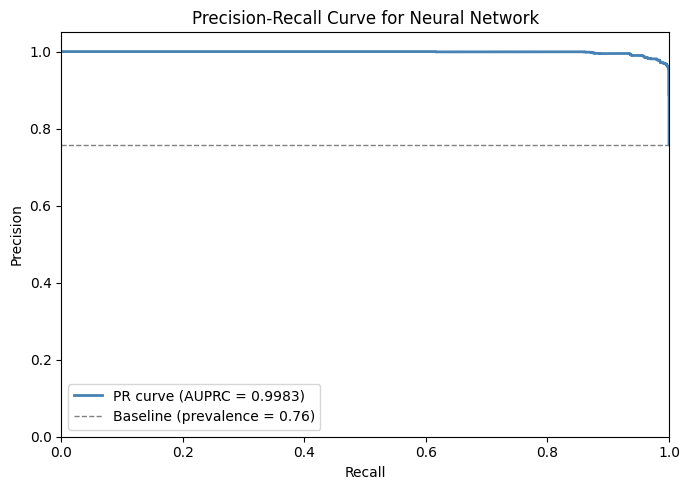

In [135]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
auprc = average_precision_score(y_test, pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUPRC = {auprc:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve for Neural Network")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

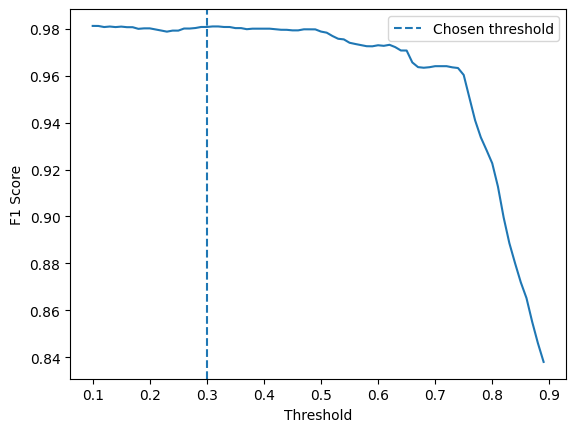

In [137]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (pred_proba >= t).astype(int)) for t in thresholds]
plt.plot(thresholds, f1_scores)
plt.axvline(x=0.3, linestyle='--', label='Chosen threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()

## Run Order
1. Cell 1: imports and constants
2. Cell 2: helper functions and model definition
3. Cell 3: full data loading
4. Cell 4: slicing and preprocessing
5. Cell 5: training
6. Cell 6: evaluation
7. Cell 7: permutation importance (display)
8. Cell 8: permutation importance (list)
9. Cell 9: save model